# Recipe 07 — Hyperparameter search with Optuna

A concrete end-to-end example: tune the PID gains `(kp, ki, kd)` for α-tracking on the linear F-16. The objective is the late-window RMSE — lower is better.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

import tensoraerospace  # noqa: F401
from tensoraerospace.agent.pid import PID
from tensoraerospace.optimization import HyperParamOptimizationOptuna
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.utils import generate_time_period

dt = 0.01
tp = generate_time_period(tn=20, dt=dt)
N = len(tp)
reference_signal = np.reshape(
    unit_step(tp=tp, degree=5, time_step=2.0, output_rad=True), (1, -1)
)

def make_env():
    env = gym.make(
        'LinearLongitudinalF16-v0',
        number_time_steps=N,
        use_reward=False,
        initial_state=[[0], [0], [0]],
        reference_signal=reference_signal,
        state_space=['theta', 'alpha', 'q'],
        output_space=['theta', 'alpha', 'q'],
        tracking_states=['alpha'],
    ).unwrapped
    env.reset()
    return env

## 2. Define the objective

In [2]:
def objective(trial):
    kp = trial.suggest_float('kp', -25.0, -3.0)
    ki = trial.suggest_float('ki', -15.0, -1.0)
    kd = trial.suggest_float('kd', -3.0, -0.1)

    env = make_env()
    pid = PID(env, kp=kp, ki=ki, kd=kd, dt=dt)

    alpha_meas = []
    xt = np.zeros(3)
    for step in range(N - 2):
        setpoint = float(reference_signal[0, step])
        ut = pid.select_action(setpoint, float(xt[1]))
        xt, *_ = env.step(np.array([ut]))
        alpha_meas.append(float(xt[1]))

    alpha_meas = np.asarray(alpha_meas)
    ref = reference_signal[0, : len(alpha_meas)]
    late = slice(-500, None)
    return float(np.sqrt(np.mean((alpha_meas[late] - ref[late]) ** 2)))

## 3. Run the study

`HyperParamOptimizationOptuna` thinly wraps `optuna.create_study` so `get_best_param` and `plot_parms` are available. 25 trials is enough for a convex-ish 3-D PID space.

In [3]:
opt = HyperParamOptimizationOptuna(direction='minimize')
opt.run_optimization(objective, n_trials=25)

best = opt.get_best_param()
print('Best gains:')
for k, v in best.items():
    print(f'  {k} = {v:+.3f}')
print(f'Best RMSE:  {opt.study.best_value:.5f} rad '
      f'({np.degrees(opt.study.best_value):.4f} deg)')

[I 2026-04-19 05:25:38,971] A new study created in memory with name: no-name-94c929ae-a341-426d-ad55-e8dec1beec17


[I 2026-04-19 05:25:39,168] Trial 0 finished with value: 0.016137569287814305 and parameters: {'kp': -11.71837565272219, 'ki': -13.05582775763725, 'kd': -1.9660032848842435}. Best is trial 0 with value: 0.016137569287814305.


[I 2026-04-19 05:25:39,209] Trial 1 finished with value: 0.0011123156492715586 and parameters: {'kp': -16.439485318764117, 'ki': -7.993072132332607, 'kd': -0.21140717857303626}. Best is trial 1 with value: 0.0011123156492715586.


[I 2026-04-19 05:25:39,248] Trial 2 finished with value: 0.00016409626104811885 and parameters: {'kp': -20.26706442345558, 'ki': -6.009374524329688, 'kd': -2.64338179933202}. Best is trial 2 with value: 0.00016409626104811885.


[I 2026-04-19 05:25:39,288] Trial 3 finished with value: 0.001239486892320357 and parameters: {'kp': -12.553528348020732, 'ki': -5.071456576947776, 'kd': -0.6241011072692313}. Best is trial 2 with value: 0.00016409626104811885.


...

[I 2026-04-19 05:25:40,045] Trial 21 finished with value: 5.2492377570789173e-05 and parameters: {'kp': -24.555373814172295, 'ki': -9.01118879222807, 'kd': -0.9980159894151693}. Best is trial 21 with value: 5.2492377570789173e-05.


[I 2026-04-19 05:25:40,089] Trial 22 finished with value: 5.978795881817285e-05 and parameters: {'kp': -24.900361936642092, 'ki': -9.371465924968929, 'kd': -1.2767042099478867}. Best is trial 21 with value: 5.2492377570789173e-05.


[I 2026-04-19 05:25:40,132] Trial 23 finished with value: 0.0005090925107028951 and parameters: {'kp': -22.137601934002188, 'ki': -11.956601363652451, 'kd': -1.4451239364208128}. Best is trial 21 with value: 5.2492377570789173e-05.


[I 2026-04-19 05:25:40,176] Trial 24 finished with value: 3.505085524128333e-05 and parameters: {'kp': -24.658925299506446, 'ki': -8.745096124926523, 'kd': -1.6750127859133914}. Best is trial 24 with value: 3.505085524128333e-05.


Best gains:
  kp = -24.659
  ki = -8.745
  kd = -1.675
Best RMSE:  0.00004 rad (0.0020 deg)


## 4. Plot the search history

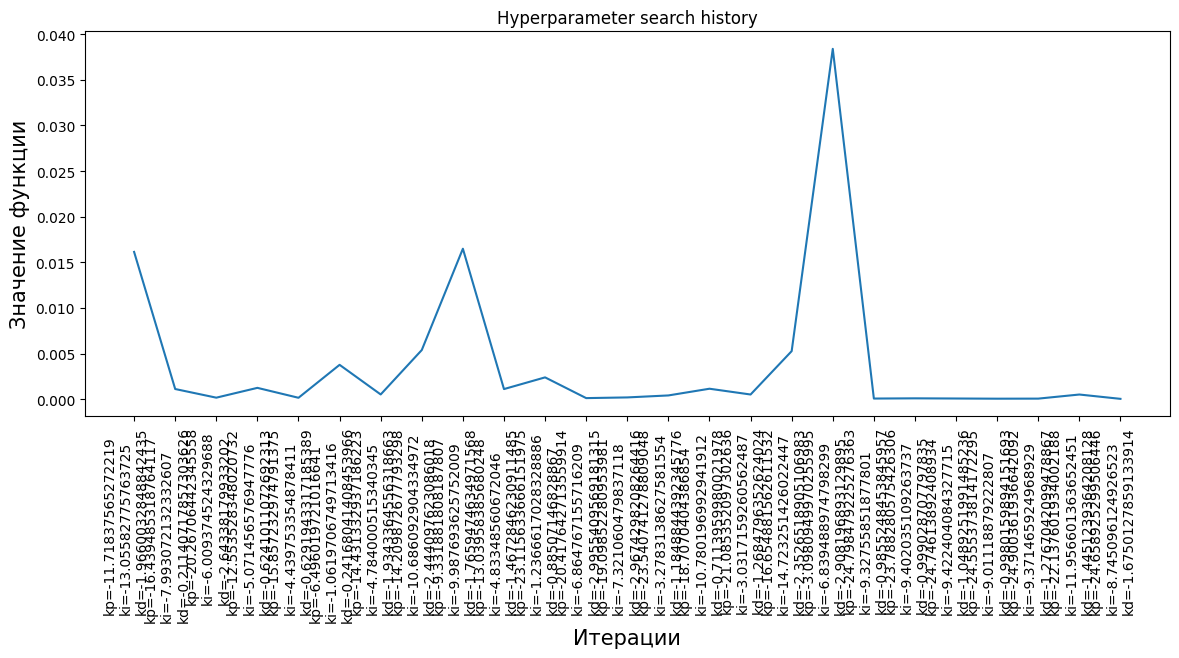

In [4]:
fig = opt.plot_parms(figsize=(14, 5))
plt.show()

## 5. Re-run the best gains and plot tracking

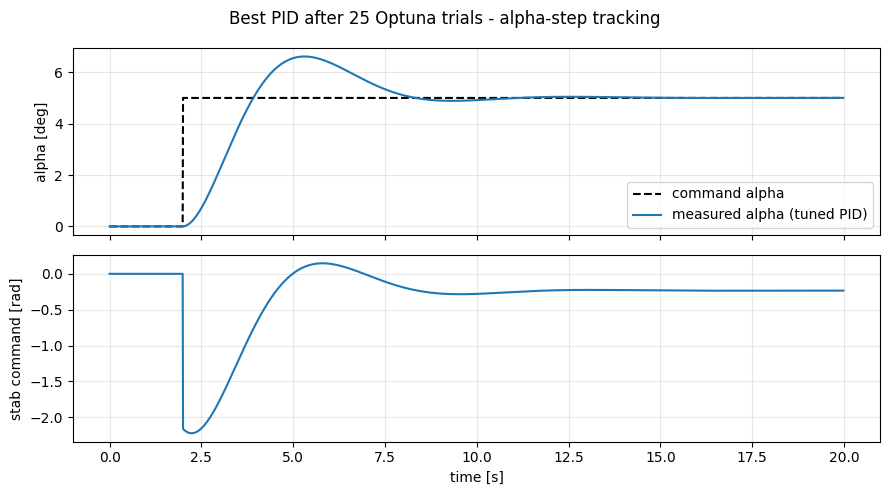

In [5]:
env = make_env()
pid = PID(env, **best, dt=dt)
alpha_meas = []; u_trace = []
xt = np.zeros(3)
for step in range(N - 2):
    setpoint = float(reference_signal[0, step])
    ut = pid.select_action(setpoint, float(xt[1]))
    xt, *_ = env.step(np.array([ut]))
    alpha_meas.append(float(xt[1])); u_trace.append(float(ut))

alpha_meas = np.asarray(alpha_meas); u_trace = np.asarray(u_trace)
ref = reference_signal[0, : len(alpha_meas)]
t = tp[: len(alpha_meas)]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, np.degrees(ref), 'k--', label='command alpha')
axes[0].plot(t, np.degrees(alpha_meas), label='measured alpha (tuned PID)')
axes[0].set_ylabel('alpha [deg]'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t, u_trace)
axes[1].set_ylabel('stab command [rad]'); axes[1].set_xlabel('time [s]'); axes[1].grid(alpha=0.3)

fig.suptitle('Best PID after 25 Optuna trials - alpha-step tracking')
plt.tight_layout(); plt.show()

## What you should see

- The **search history** panel shows the objective converging; later trials cluster tightly around the best gains.
- The tracking plot matches the 5° command; RMSE lands in the **< 0.1°** range after 25 trials.
- If your numbers differ substantially, sanity-check `number_time_steps`, `dt`, and that `tracking_states=['alpha']`. Optuna's random-seed variation is small (±10 % on the RMSE) but not zero.